# HMBA Subcortex: 10X gene expression

In this notebook we'll explore gene expressions and combine them with the cell metadata we showed in the [previous clustering analysis](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_subcortex_clustering_analysis_and_annotation.html) tutorial.

You need to be connected to the internet to run this notebook or connected to a cache that has the HMBA-10XMultiome-Subcortex data downloaded already.

The notebook presented here shows quick visualizations from precomputed metadata in the atlas. For examples on accessing the expression matrices, specifically selecting genes from expression matrices, see the [general Accessing expression data](https://alleninstitute.github.io/abc_atlas_access/notebooks/general_accessing_10x_snRNASeq_tutorial.html) tutorial.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple

from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data

We will interact with the data using the **AbcProjectCache**. This cache object tracks which data has been downloaded and serves the path to the requested data on disk. For metadata, the cache can also directly serve up a Pandas DataFrame. See the [``getting_started``](https://alleninstitute.github.io/abc_atlas_access/notebooks/getting_started.html) notebook for more details on using the cache including installing it if it has not already been. 

**Change the download_base variable to where you would like to download the data to your system or a location where a cache is already available.**

In [2]:
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(
    cache_dir=download_base,
    s3_bucket='allen-brain-cell-atlas-staging',
    auth_required=True
)

abc_cache.current_manifest

'releases/20261031/manifest.json'

Below we create the expanded cell metadata as was done previously in the [cluster annotation tutorial](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_subcortex_clustering_analysis_and_annotation.html).

In [3]:
cell_to_cluster_membership = abc_cache.get_metadata_dataframe(
    'HMBA-Subcortex-taxonomy', 'cell_to_cluster_membership'
).set_index('cell_label')
cluster = abc_cache.get_metadata_dataframe(
    'HMBA-Subcortex-taxonomy', 'cluster'
).set_index('label')
cluster_annotation_term = abc_cache.get_metadata_dataframe(
    'HMBA-Subcortex-taxonomy', 'cluster_annotation_term'
).set_index('label')

cluster_annotation_term_set = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_annotation_term_set'
).set_index('label')

cluster_to_cluster_annotation_membership = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_to_cluster_annotation_membership'
).set_index('cluster_annotation_term_label')

cell_metadata = abc_cache.get_metadata_dataframe('HMBA-10xMultiome-Subcortex', 'cell_metadata').set_index('cell_label')
membership_with_cluster_info = cluster_to_cluster_annotation_membership.join(
    cluster.reset_index().set_index('cluster_alias')[['number_of_cells']],
    on='cluster_alias'
)

membership_with_cluster_info = membership_with_cluster_info.join(cluster_annotation_term, rsuffix='_anno_term').reset_index()

membership_groupby = membership_with_cluster_info.groupby(
    ['cluster_alias', 'cluster_annotation_term_set_name']
)

cluster_details = membership_groupby['cluster_annotation_term_name'].first().unstack()
cluster_order = membership_groupby['term_order'].first().unstack()

cluster_colors = membership_groupby['color_hex_triplet'].first().unstack()
cluster_colors = cluster_colors[cluster_annotation_term_set['name']]

cell_extended = cell_metadata.join(cell_to_cluster_membership, how='inner')
cell_extended = cell_extended.join(cluster_details, on='cluster_alias')
cell_extended = cell_extended.join(cluster_colors, on='cluster_alias', rsuffix='_color')
cell_extended = cell_extended.join(cluster_order, on='cluster_alias', rsuffix='_order')

barcoded_cell_samples = abc_cache.get_metadata_dataframe(
    directory='HMBA-10xMultiome-Subcortex',
    file_name='barcoded_cell_sample'
).set_index('barcoded_cell_sample_label')
donor = abc_cache.get_metadata_dataframe(
    directory='HMBA-10xMultiome-Subcortex',
    file_name='donor'
).set_index('donor_label')

cell_extended = cell_extended.join(barcoded_cell_samples, on='barcoded_cell_sample_label', rsuffix='_bc')
cell_extended = cell_extended.join(donor, on='donor_label', rsuffix='_donor')

value_sets = abc_cache.get_metadata_dataframe(
    directory='HMBA-10xMultiome-Subcortex',
    file_name='value_sets'
).set_index('label')

cluster_to_dominant_region = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_to_dominant_region',
).set_index('cluster_alias')
cluster_to_neurotransmitter = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_to_neurotransmitter',
).set_index('cluster_alias')

cell_extended = cell_extended.join(cluster_to_dominant_region, on='cluster_alias')
cell_extended = cell_extended.join(cluster_to_neurotransmitter, on='cluster_alias')

def extract_value_set(
        cell_metadata_df: pd.DataFrame,
        input_value_set: pd.DataFrame,
        input_value_set_label: str,
        dataframe_column: Optional[str] = None
    ):
    """Add color and order columns to the cell metadata dataframe based on the input
    value set.

    Columns are added as {input_value_set_label}_color and {input_value_set_label}_order.

    Parameters
    ----------
    cell_metadata_df : pd.DataFrame
        DataFrame containing cell metadata.
    input_value_set : pd.DataFrame
        DataFrame containing the value set information.
    input_value_set_label : str
        The the column name to extract color and order information for. will be added to the cell metadata.
    """
    if dataframe_column is None:
        dataframe_column = input_value_set_label
    cell_metadata_df[f'{dataframe_column}_color'] = input_value_set[
        input_value_set['field'] == input_value_set_label
    ].loc[cell_metadata_df[dataframe_column]]['color_hex_triplet'].values
    cell_metadata_df[f'{dataframe_column}_order'] = input_value_set[
        input_value_set['field'] == input_value_set_label
    ].loc[cell_metadata_df[dataframe_column]]['order'].values

# Add region of interest color and order
extract_value_set(cell_extended, value_sets, 'region_of_interest_label')
# Add species common name color and order
extract_value_set(cell_extended, value_sets, 'species_genus')
# Add species scientific name color and order
extract_value_set(cell_extended, value_sets, 'species_scientific_name')
# Add donor sex color and order
extract_value_set(cell_extended, value_sets, 'donor_sex')
cell_extended.head()

,barcoded_cell_sample_label,nCount_RNA,nFeature_RNA,doublet_score,donor_label,alignment_job_id,In_BG_taxonomy_dataset,feature_matrix_label,dataset_label,cluster_alias,...,Group_NT,Group_NT_color,region_of_interest_label_color,region_of_interest_label_order,species_genus_color,species_genus_order,species_scientific_name_color,species_scientific_name_order,donor_sex_color,donor_sex_order
cell_label,,,,,,,,,,,,,,,,,,,,,
GTTCCTGGTTAGCATG-P0005_1,P0005_1,33732,6363,0.118006,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_1,...,Other,#7f7f7f,#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2
TACTGAGGTTAGGATT-P0005_1,P0005_1,29309,6123,0.520672,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_17,...,GABA,#ef3a5b,#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2
TCTTCAAGTTTATGGG-P0005_1,P0005_1,28284,5758,0.125381,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_42,...,GABA,#ef3a5b,#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2
CCCTCAGTCAGCACCA-P0005_1,P0005_1,25495,5729,0.225403,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_41,...,GABA,#ef3a5b,#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2
AACTACTCACCTACTT-P0005_1,P0005_1,23770,5132,0.557602,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_18,...,GABA,#ef3a5b,#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2


### Single nucleus transcriptomes

Below we use the convenience function `get_gene_data` to download and extract specific genes from the gene expression h5ad files. This function can be used to pull expression for the full set of cells or any subset from the set of cell metadata for specific genes. See [accessing gene expression data tutorial](https://alleninstitute.github.io/abc_atlas_access/notebooks/general_accessing_10x_snRNASeq_tutorial.html) for more information.

We first load the set of genes for these data.

In [4]:
gene = abc_cache.get_metadata_dataframe(
    directory='HMBA-10xMultiome-BG',
    file_name='marmoset_gene'
).set_index('gene_identifier')
gene.head(5)

marmoset_gene.csv: 100%|██████████| 2.61M/2.61M [00:00<00:00, 8.43MMB/s]


,gene_symbol,description,molecular_type
gene_identifier,,,
NCBIGene:118152095,LOC118152095,glucose-6-phosphate 1-dehydrogenase-like,transcribed_pseudogene
NCBIGene:118147983,LOC118147983,U6 spliceosomal RNA,snRNA
NCBIGene:100395011,LOC100395011,alpha-internexin-like,pseudogene
NCBIGene:118147921,LOC118147921,U4 spliceosomal RNA,snRNA
NCBIGene:100385748,LOC100385748,heterogeneous nuclear ribonucleoprotein A1-like,protein_coding


Below we list the genes we will use in this notebook and the example method used to load the expression for these specific genes from the h5ad file.

To process and extract the gene expressions for yourself, uncomment the code block below. Warning that this is a large amount of data and may take a significant fraction of time to download. This download action will only need to be performed once, however.

For more details on how to extract specific genes from the data see our [accessing gene expression data tutorial](https://alleninstitute.github.io/abc_atlas_access/notebooks/general_accessing_10x_snRNASeq_tutorial.html)

In [ ]:
gene_names = ['APOE', 'DRD1', 'DRD2', 'AQP4', 'FLT1', 'MME', 'RELN', 'LRP8']

gene_data = get_gene_data(
    abc_atlas_cache=abc_cache,
    all_cells=cell_metadata,
    all_genes=gene,
    selected_genes=gene_names
)

loading file: HMBA-10xMultiome-Subcortex


HMBA-10xMultiome-Subcortex-log2.h5ad:   0%|          | 0.00/6.86G [00:00<?, ?MB/s]

HMBA-10xMultiome-Subcortex-log2.h5ad: 100%|██████████| 6.86G/6.86G [05:05<00:00, 22.4MMB/s]    


Instead of processing the gene expressions, we load pre-processed files containing the log gene expression for the genes listed above. The expression in the table below are presented as log2(CPM + 1).

In [ ]:
"""
gene_data = abc_cache.get_metadata_dataframe(
    directory='SEA-AD-CaH-10X',
    file_name='example_gene_expression'
).set_index('cell_label')
gene_data.head()
"""

example_gene_expression.csv: 100%|██████████| 63.9M/63.9M [00:07<00:00, 8.34MMB/s]  


,LRP8,MME,DRD1,RELN,DRD2,FLT1,AQP4,APOE
cell_label,,,,,,,,
AAACCCAAGAATCTAG-1336_B04,0.000000,9.551004,0.000000,0.000000,8.967003,0.0,0.0,0.000000
AAACCCAAGCACAAAT-1336_B04,0.000000,7.085803,4.805742,7.759886,0.000000,0.0,0.0,0.000000
AAACCCAAGGGACTGT-1336_B04,0.000000,8.640949,0.000000,0.000000,7.063197,0.0,0.0,0.000000
AAACCCACAATTTCCT-1336_B04,0.000000,7.689756,0.000000,0.000000,0.000000,0.0,0.0,7.689756
AAACCCACAGCAATTC-1336_B04,8.706808,0.000000,8.706808,0.000000,0.000000,0.0,0.0,0.000000


We load and merge the expression into each of our cell metadata.

In [ ]:
cell_extended = cell_extended.join(gene_data)

## Example use cases

In this section, we show a use case plotting our sets of genes. First we'll show the gene expression in heatmaps plotted disease metadata and the taxonomy. We'll then plot the genes in a UMAP.

### Heatmap of Average gene expression

The helper function below creates a heatmap showing the relation between various parameters in the combined cell metadata and the genes we loaded.

In [ ]:
import matplotlib as mpl

def plot_heatmap(
    df: pd.DataFrame,
    gnames: List[str],
    value: str,
    sort: bool = False,
    fig_width: float = 8,
    fig_height: float = 4,
    vmax: float = None,
    cmap: plt.cm = plt.cm.magma,
):
    """Plot a heatmap of gene expression values for a list of genes across species.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing cell metadata and gene expression values.
    gnames : list
        List of gene names to plot.
    value : str
        Column name in df to group by (e.g., 'species_genus').
    sort : bool, optional
        Whether to sort the gene expression values within each species.
    fig_width : float, optional
        Width of the figure in inches.
    fig_height : float, optional
        Height of the figure in inches.
    vmax : float, optional
        Maximum value for the color scale. If None, it is set to the maximum value in the data.
    cmap : matplotlib colormap, optional
        Colormap to use for the heatmap.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object containing the heatmap.
    ax : array of matplotlib.axes.Axes
        The axes objects for each species.
    """

    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(fig_width, fig_height)

    grouped = df.groupby(value)[gnames].mean()
    vmin = grouped.min().min()
    vmax = grouped.max().max()
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cmap = sm.get_cmap()

    if sort:
        grouped = grouped.sort_values(by=gnames[0], ascending=False)
        grouped = grouped.loc[sorted(grouped.index)]

    value_order = df.groupby(value)[[f'{value}_order']].first()
    grouped = grouped.loc[
        value_order.sort_values(f'{value}_order').index
    ]

    arr = grouped.to_numpy().astype('float')

    ax.imshow(arr, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    xlabs = grouped.columns.values
    ylabs = grouped.index.values


    ax.set_yticks(range(len(ylabs)))
    ax.set_yticklabels(ylabs)
    ax.set_xticks(range(len(xlabs)))
    ax.set_xticklabels(xlabs)

    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.01, pad=0.01)
    cbar.set_label('Mean Expression [log2(CPM + 1)]')
    plt.subplots_adjust(wspace=0.00, hspace=0.00)
    
    return fig, ax

We now use the above function to show the average expression across neighborhood, subclass, and supertype.

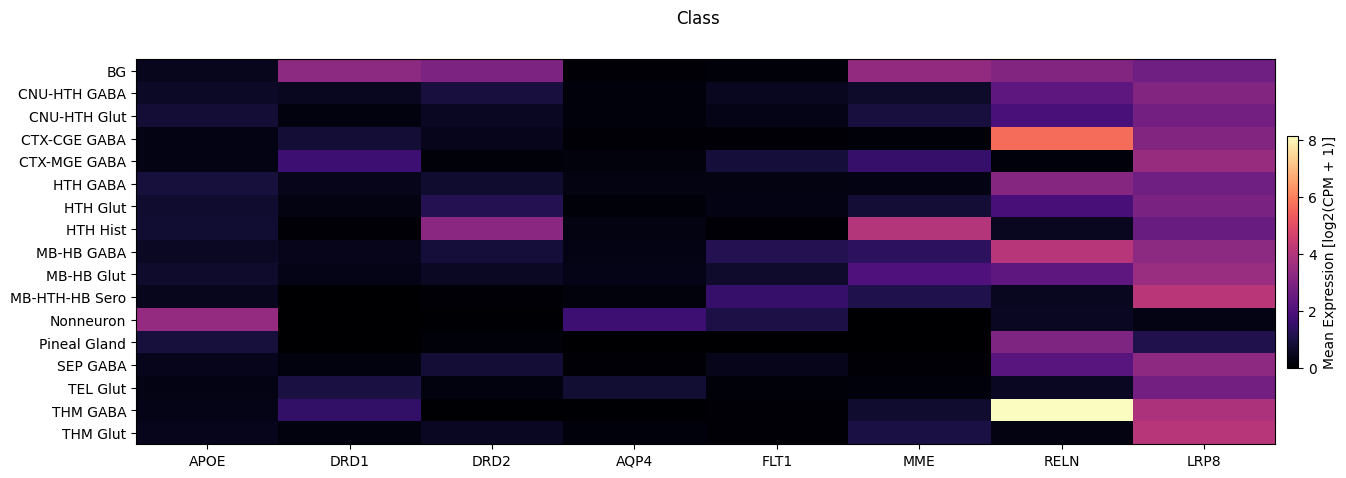

In [ ]:
fig, ax = plot_heatmap(
    df=cell_extended,
    gnames=gene_names,
    value='Class',
    fig_width=15,
    fig_height=5
)
fig.suptitle('Class')
plt.show()

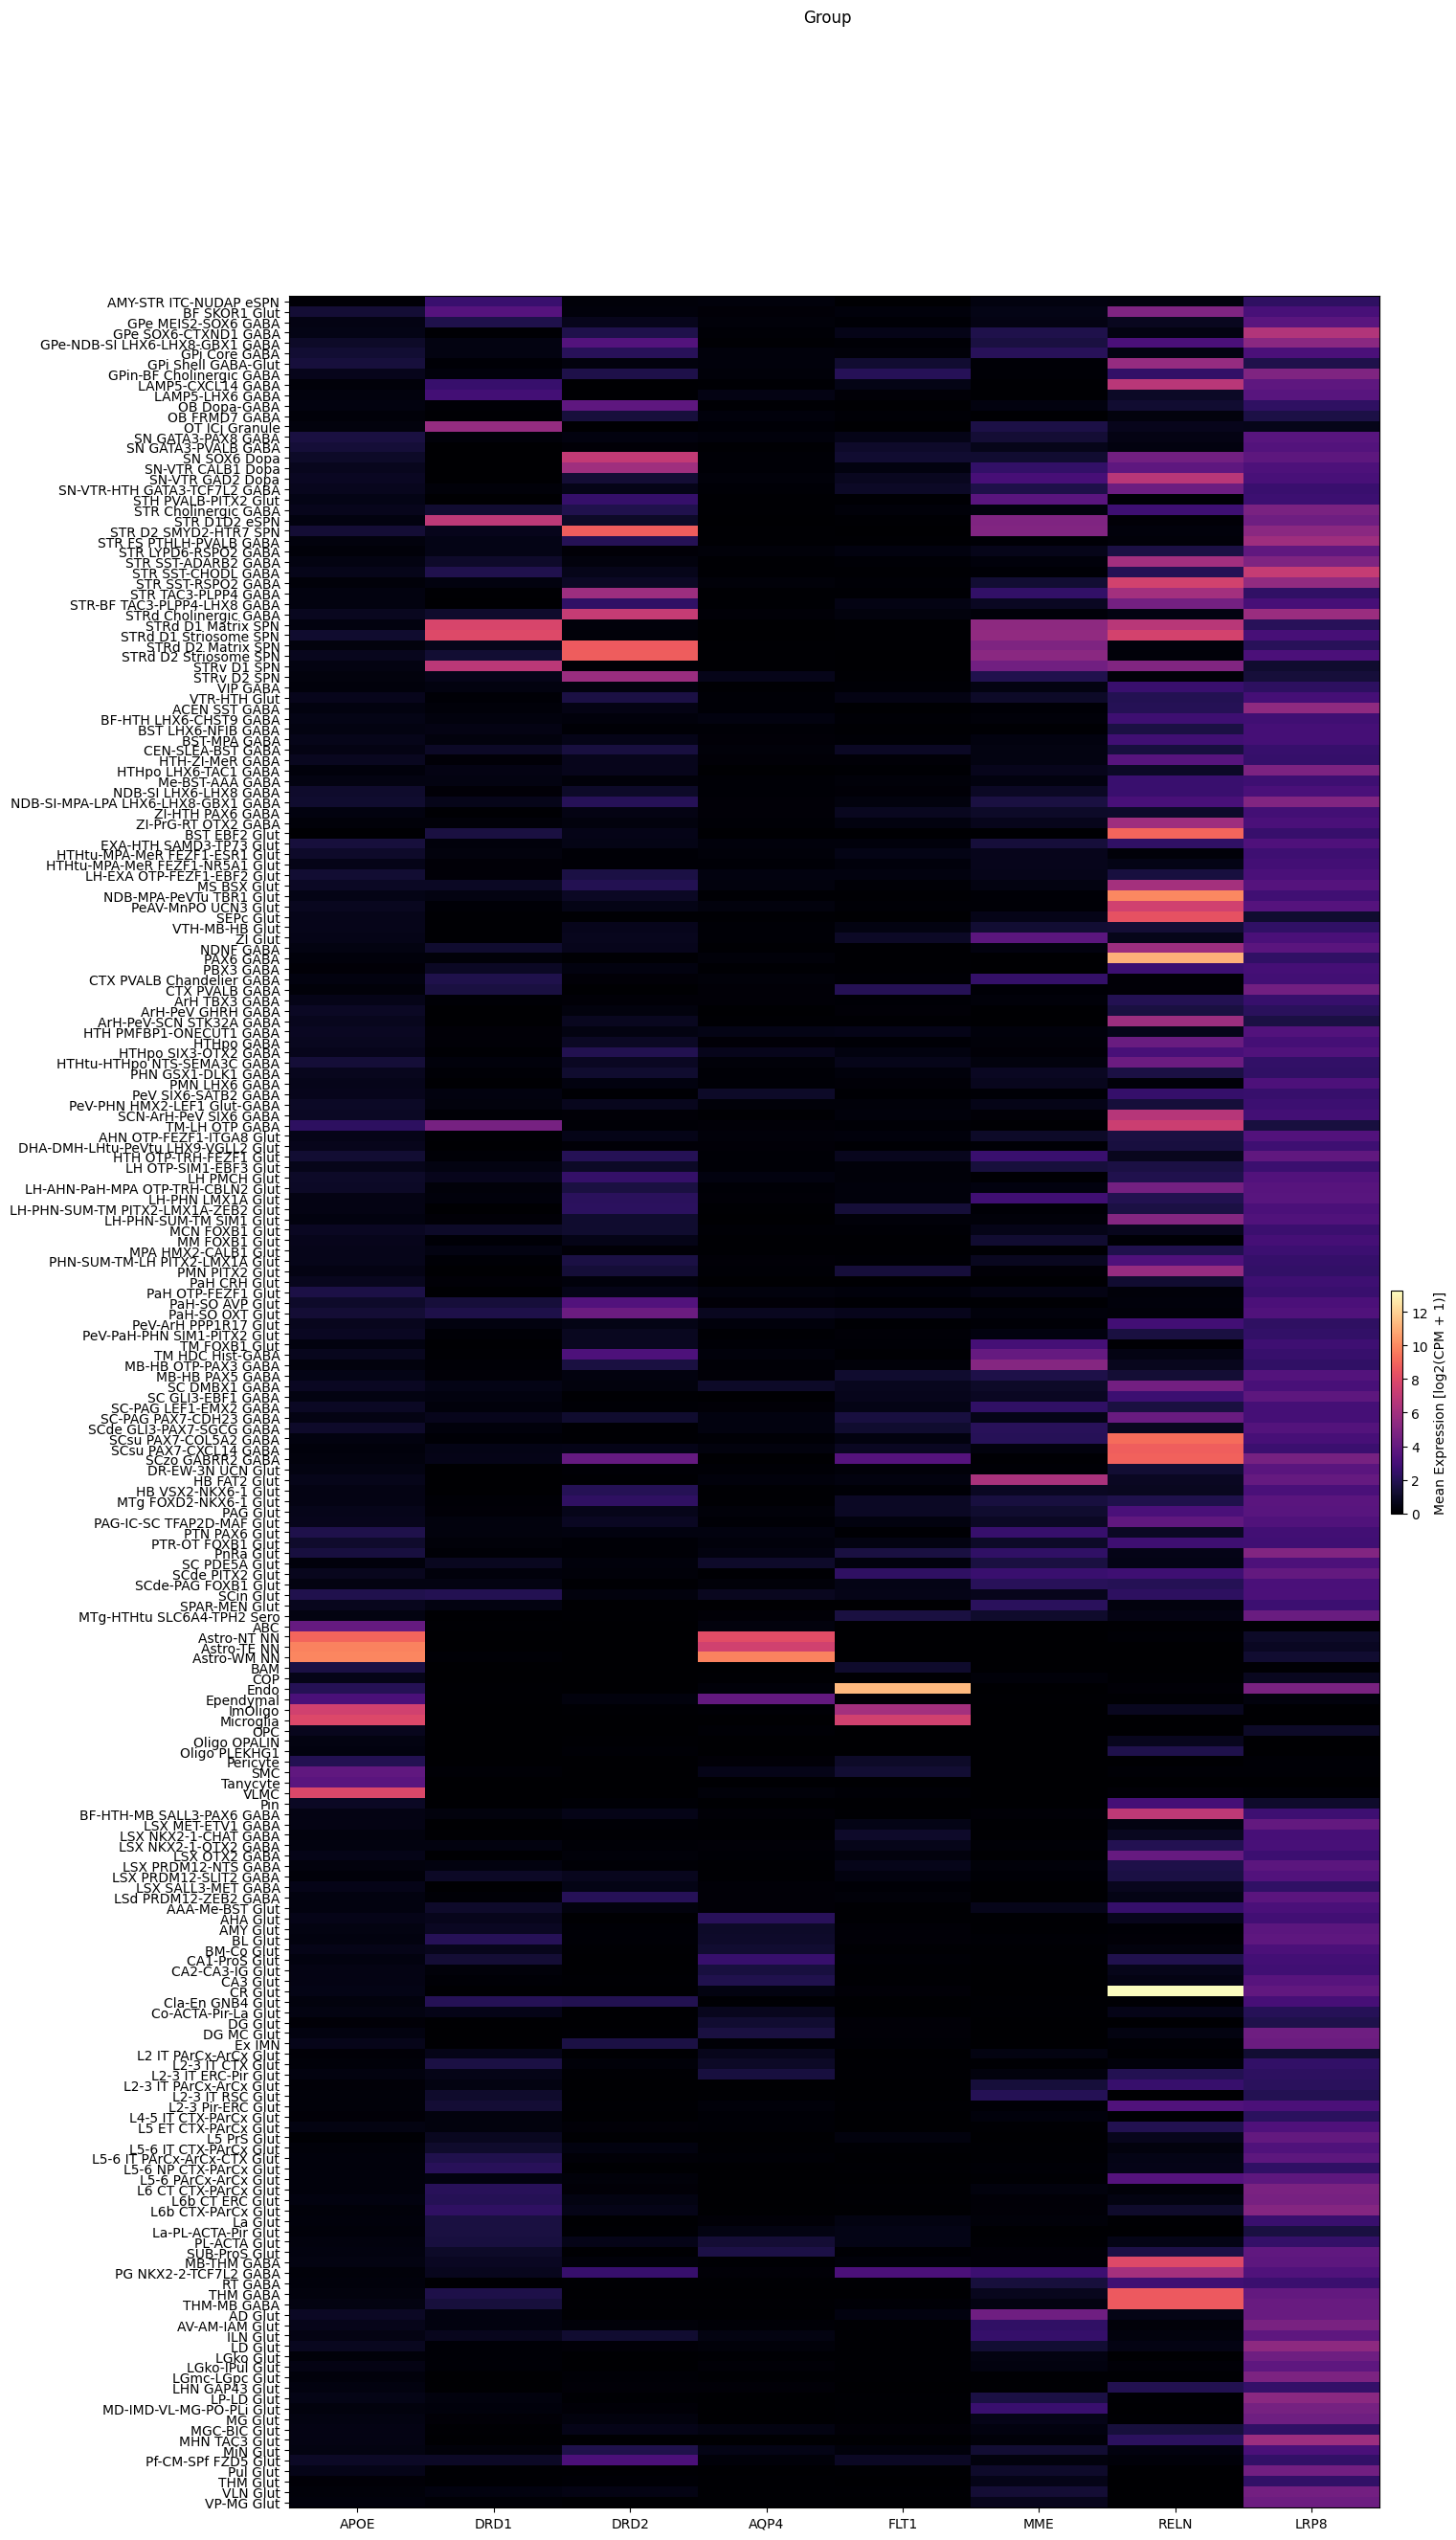

In [ ]:
fig, ax = plot_heatmap(
    df=cell_extended,
    gnames=gene_names,
    value='Group',
    fig_width=15,
    fig_height=30,
    sort=True
)
fig.suptitle('Group')
plt.show()

In [ ]:
fig, ax = plot_heatmap(
    df=cell_extended,
    gnames=gene_names,
    value='Group_Dominant_Region',
    fig_width=15,
    fig_height=30,
    sort=True
)
fig.suptitle('Group Dominant Region')
plt.show()

## Expression in the UMAP

We load the UMAP coordinates for our cells and plot the expression in the UMAP for each of our selected genes. The UMAP is the same as the [previous notebook](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_subcortex_clustering_analysis_and_annotation.html).

In [ ]:
cell_2d_embedding_coordinates = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cell_2d_embedding_coordinates'
).set_index('cell_label')
cell_2d_embedding_coordinates.head()

,x,y
cell_label,,
GTTCCTGGTTAGCATG-P0005_1,14.662888,10.134843
TACTGAGGTTAGGATT-P0005_1,-8.280969,18.335058
TCTTCAAGTTTATGGG-P0005_1,7.183354,13.461928
CCCTCAGTCAGCACCA-P0005_1,7.140094,13.440581
AACTACTCACCTACTT-P0005_1,-8.869915,18.777521


Join the coordinates into the cell metadata.

In [ ]:
cell_extended = cell_extended.join(
    cell_2d_embedding_coordinates,
    how='inner'
).sample(frac=1)
cell_extended.head()

,barcoded_cell_sample_label,nCount_RNA,nFeature_RNA,doublet_score,donor_label,alignment_job_id,In_BG_taxonomy_dataset,feature_matrix_label,dataset_label,cluster_alias,...,DRD1,FLT1,LRP8,RELN,DRD2,AQP4,MME,APOE,x,y
cell_label,,,,,,,,,,,,,,,,,,,,,
ACTAATCCATGCTTAG-P0047_1,P0047_1,3342,1885,0.027551,CJ24.56.001,241212,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_846,...,0.000000,9.811642,0.000000,0.000000,0.000000,0.0,0.000000,10.547965,12.701927,1.051416
AGACACGCATTATGGT-P0043_2,P0043_2,37432,6837,0.127621,CJ23.56.003,240807,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_694,...,0.000000,0.000000,5.766336,4.792601,0.000000,0.0,4.792601,0.000000,-1.943266,9.403436
GGTTAGCGTTCCTGTG-P0074_3,P0074_3,13139,4288,0.070378,CJ24.56.004,250114,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_127,...,6.268833,0.000000,0.000000,0.000000,8.838119,0.0,6.268833,0.000000,6.762805,16.053005
CGGCTCACAAACTGCC-P0052_1,P0052_1,19292,5927,0.120548,CJ24.56.001,241212,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_312,...,0.000000,0.000000,5.723421,7.702795,0.000000,0.0,0.000000,0.000000,-5.337596,8.103431
ACCTCACTCATTACAG-P0071_2,P0071_2,10704,4240,0.549476,CJ24.56.001,250114,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,cluster_1065,...,0.000000,0.000000,6.561067,0.000000,0.000000,0.0,0.000000,0.000000,0.079486,-0.098493


We use the same UMAP plotting convenience function as previously used in the [HMBA-Subcortex clustering and annotation tutorial](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_subcortex_clustering_analysis_and_annotation.html).

In [ ]:
def plot_umap(
    xx: np.ndarray,
    yy: np.ndarray,
    cc: np.ndarray = None,
    val: np.ndarray = None,
    fig_width: float = 8,
    fig_height: float = 8,
    cmap: Optional[plt.Colormap] = None,
    labels: np.ndarray = None,
    term_orders: np.ndarray = None,
    colorbar: bool = False,
    sizes: np.ndarray = None,
    fig: plt.Figure = None,
    ax: plt.Axes = None,
 ) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot a scatter plot of the UMAP coordinates.

    Parameters
    ----------
    xx : array-like
        x-coordinates of the points to plot.
    yy : array-like
        y-coordinates of the points to plot.
    cc : array-like, optional
        colors of the points to plot. If None, the points will be colored by the values in `val`.
    val : array-like, optional
        values of the points to plot. If None, the points will be colored by the values in `cc`.
    fig_width : float, optional
        width of the figure in inches. Default is 8.
    fig_height : float, optional
        height of the figure in inches. Default is 8.
    cmap : str, optional
        colormap to use for coloring the points. If None, the points will be colored by the values in `cc`.
    labels : array-like, optional
        labels for the points to plot. If None, no labels will be added to the plot.
    term_orders : array-like, optional
        order of the labels for the legend. If None, the labels will be ordered by their appearance in `labels`.
    colorbar : bool, optional
        whether to add a colorbar to the plot. Default is False.
    sizes : array-like, optional
        sizes of the points to plot. If None, all points will have the same size.
    fig : matplotlib.figure.Figure, optional
        figure to plot on. If None, a new figure will be created with 1 subplot.
    ax : matplotlib.axes.Axes, optional
        axes to plot on. If None, a new figure will be created with 1 subplot.
    """

    if sizes is None:
        sizes = 1
    if ax is None or fig is None:
        fig, ax = plt.subplots()
        fig.set_size_inches(fig_width, fig_height)

    if cmap is not None:
        scatt = ax.scatter(xx, yy, c=val, s=0.5, marker='.', cmap=cmap, alpha=sizes)
    elif cc is not None:
        scatt = ax.scatter(xx, yy, c=cc, s=0.5, marker='.', alpha=sizes)

    if labels is not None:
        from matplotlib.patches import Rectangle
        unique_label_colors = (labels + ',' + cc).unique()
        unique_labels = np.array([label_color.split(',')[0] for label_color in unique_label_colors])
        unique_colors = np.array([label_color.split(',')[1] for label_color in unique_label_colors])

        if term_orders is not None:
            unique_order = term_orders.unique()
            term_order = np.argsort(unique_order)
            unique_labels = unique_labels[term_order]
            unique_colors = unique_colors[term_order]
            
        rects = []
        for color in unique_colors:
            rects.append(Rectangle((0, 0), 1, 1, fc=color))

        legend = ax.legend(rects, unique_labels, loc=0)
        # ax.add_artist(legend)
    
    ax.set_xticks([])
    ax.set_yticks([])

    if colorbar:
        fig.colorbar(scatt, ax=ax)
    
    return fig, ax

Below we plot the genes in our set next to the UMAP colored by one of our features.

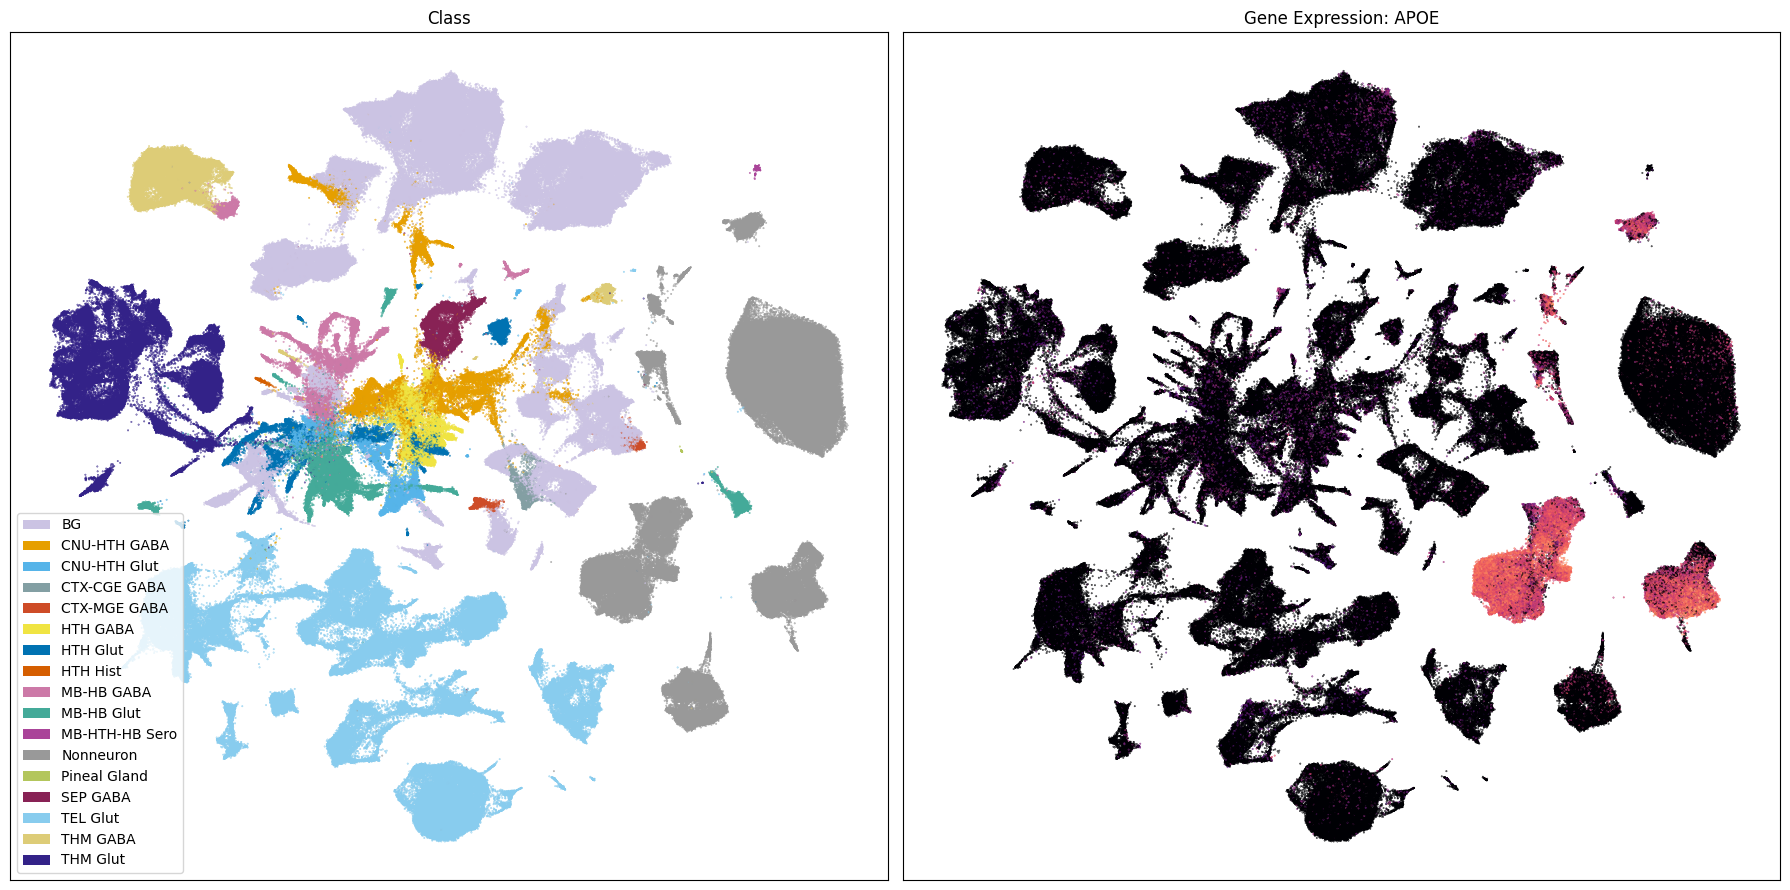

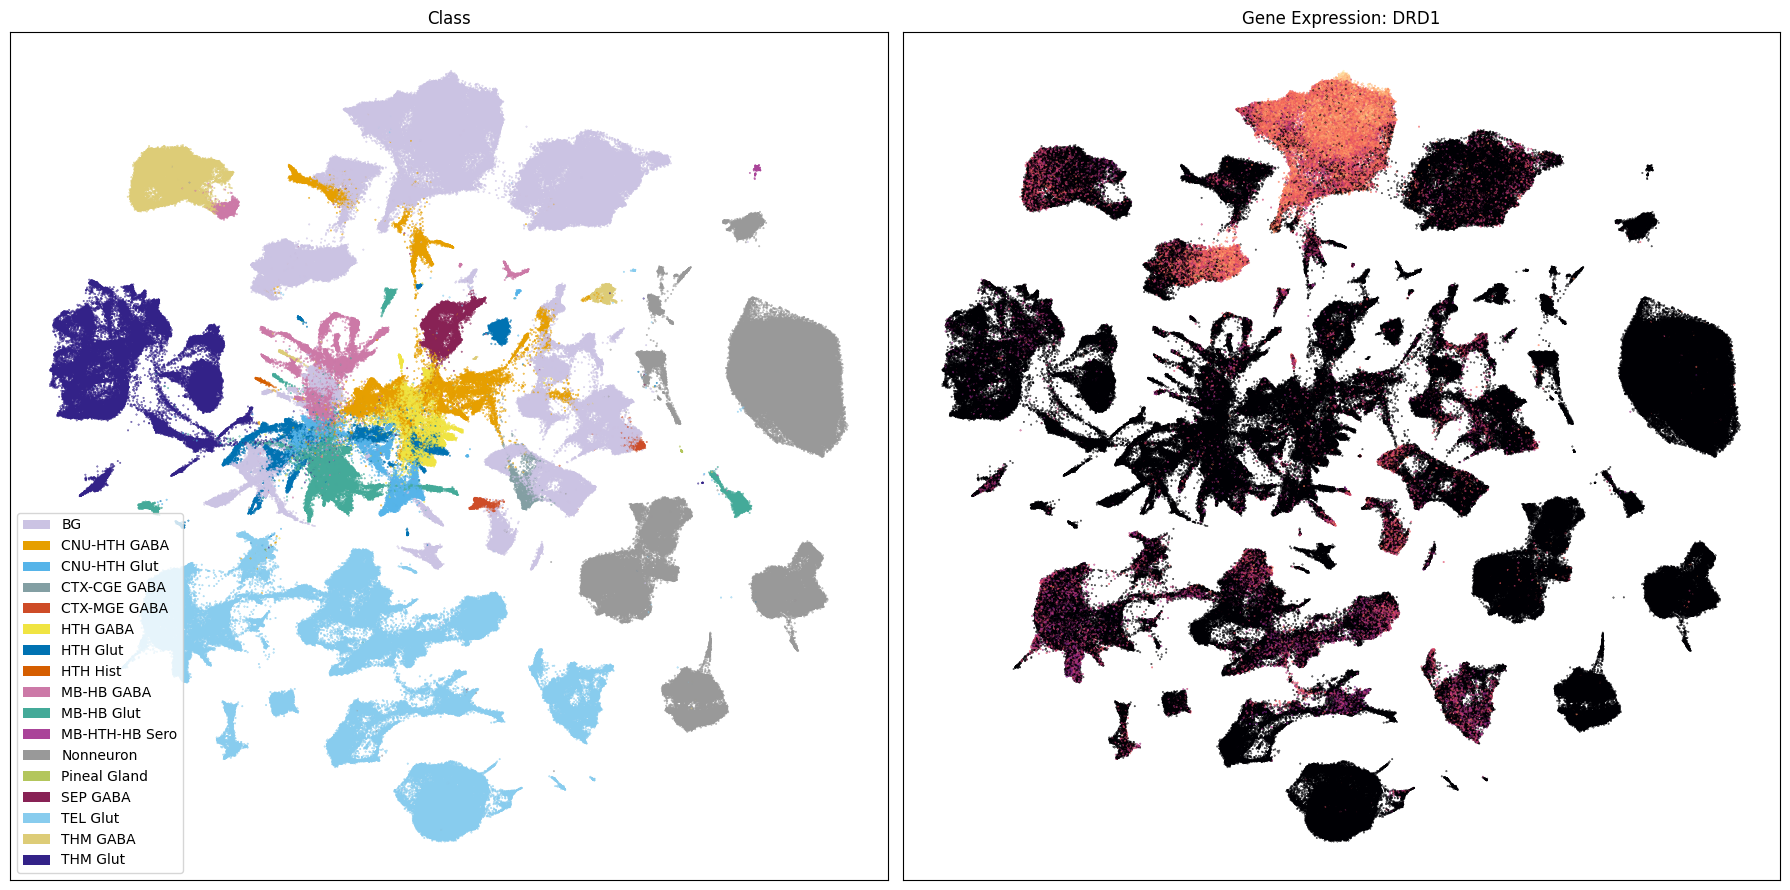

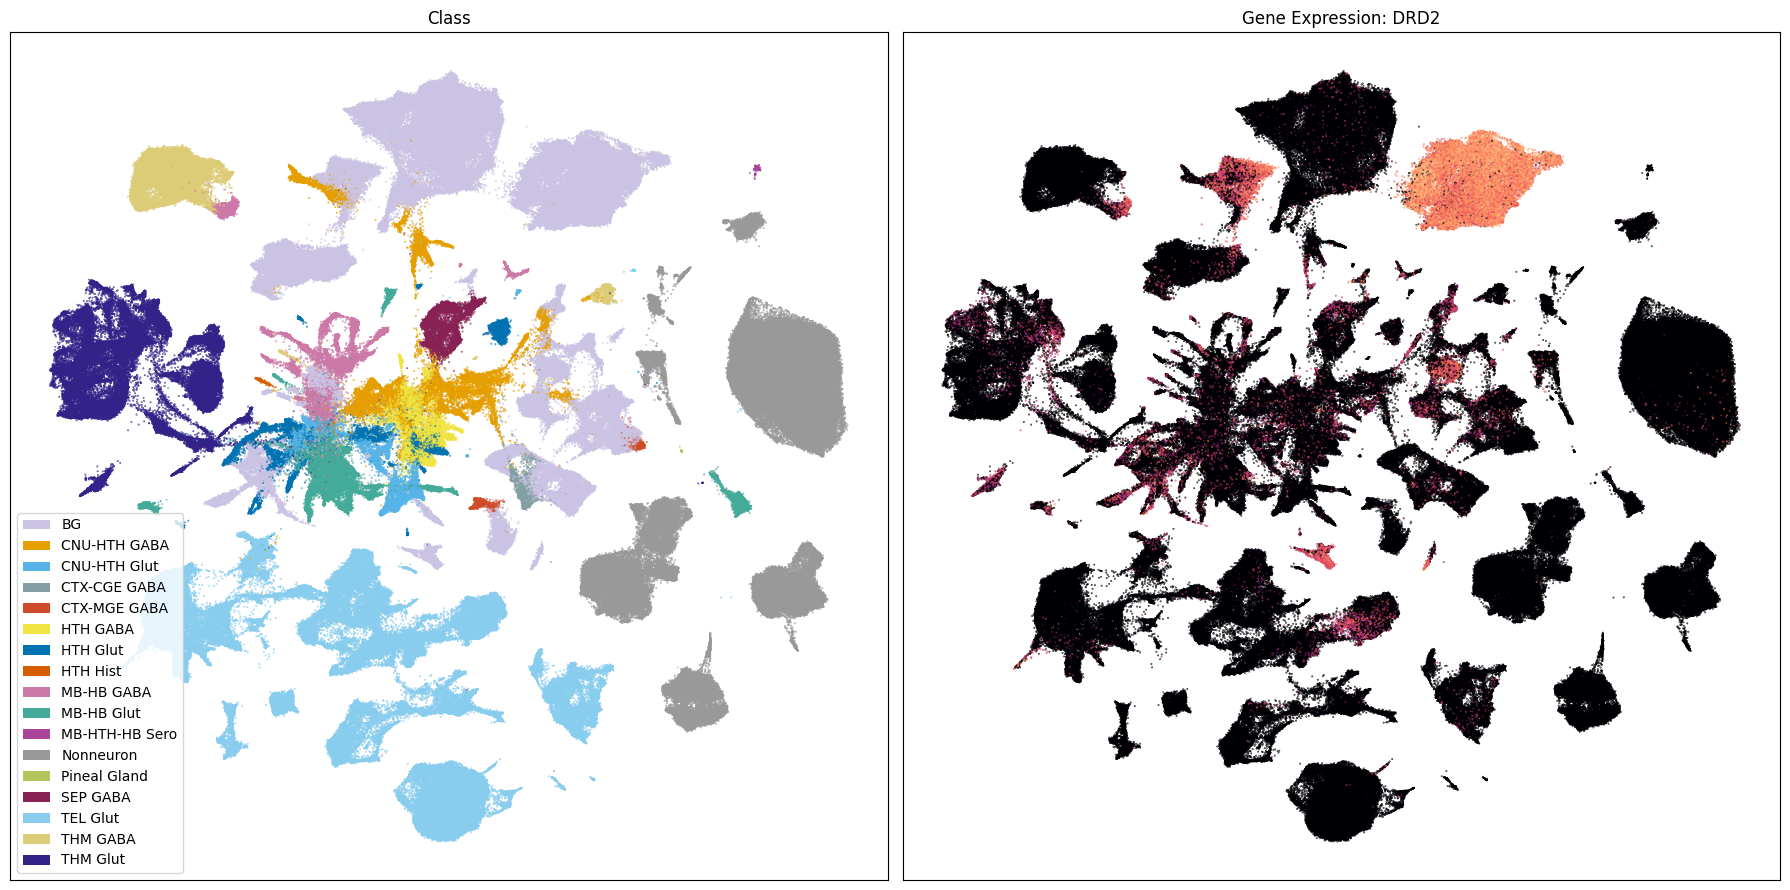

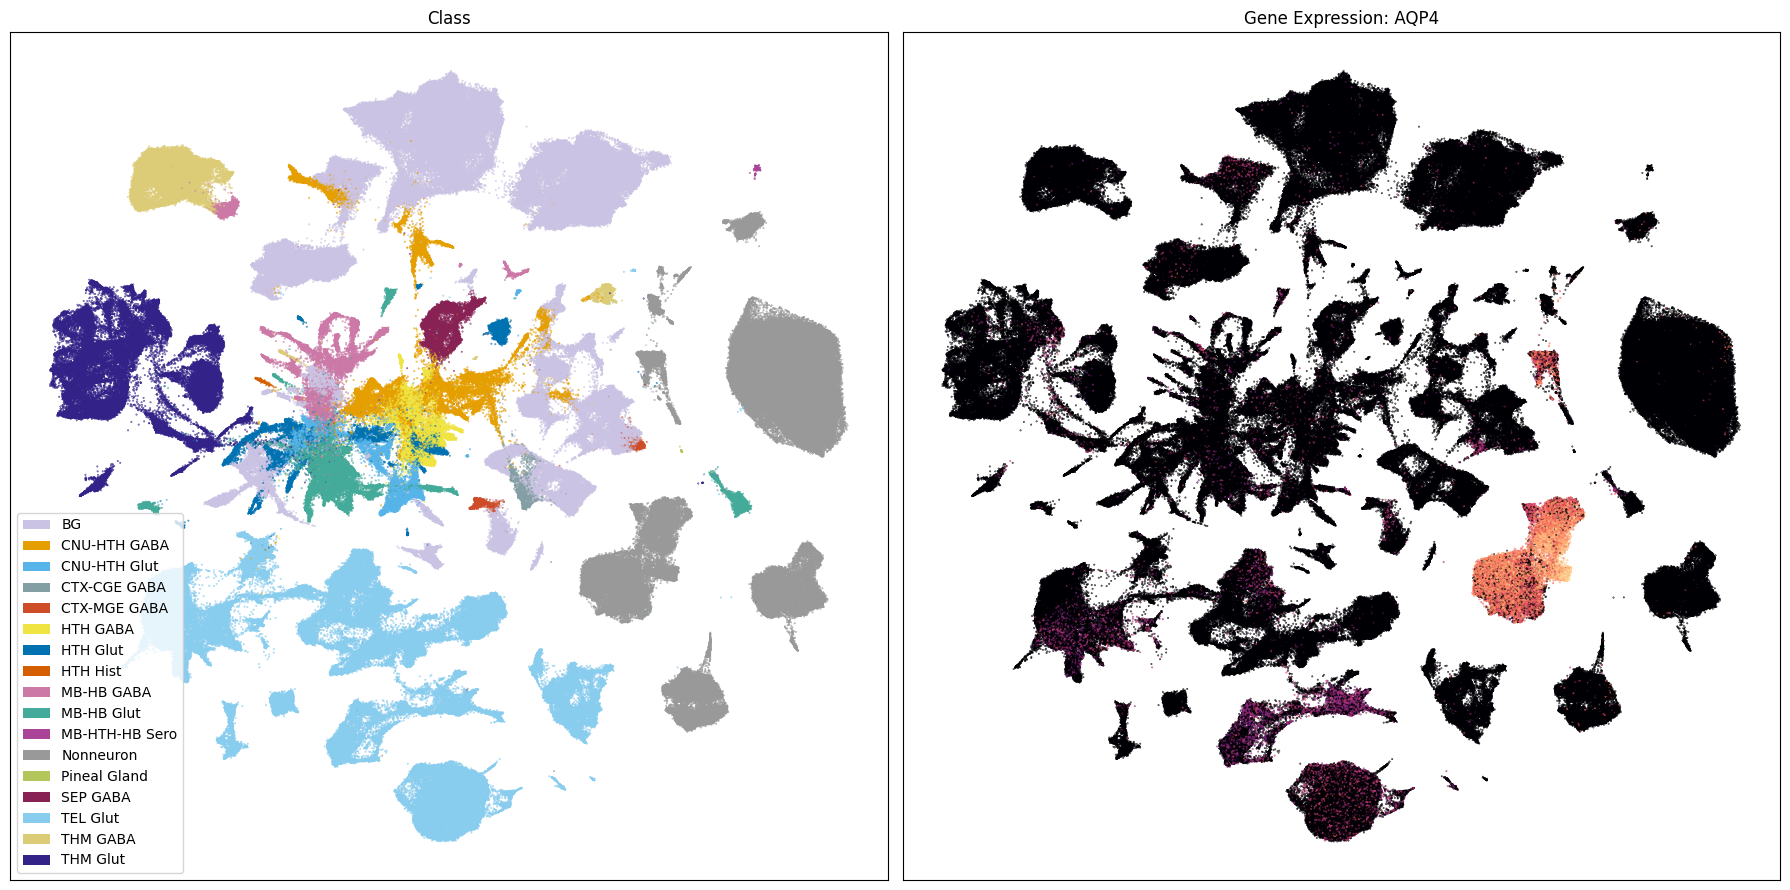

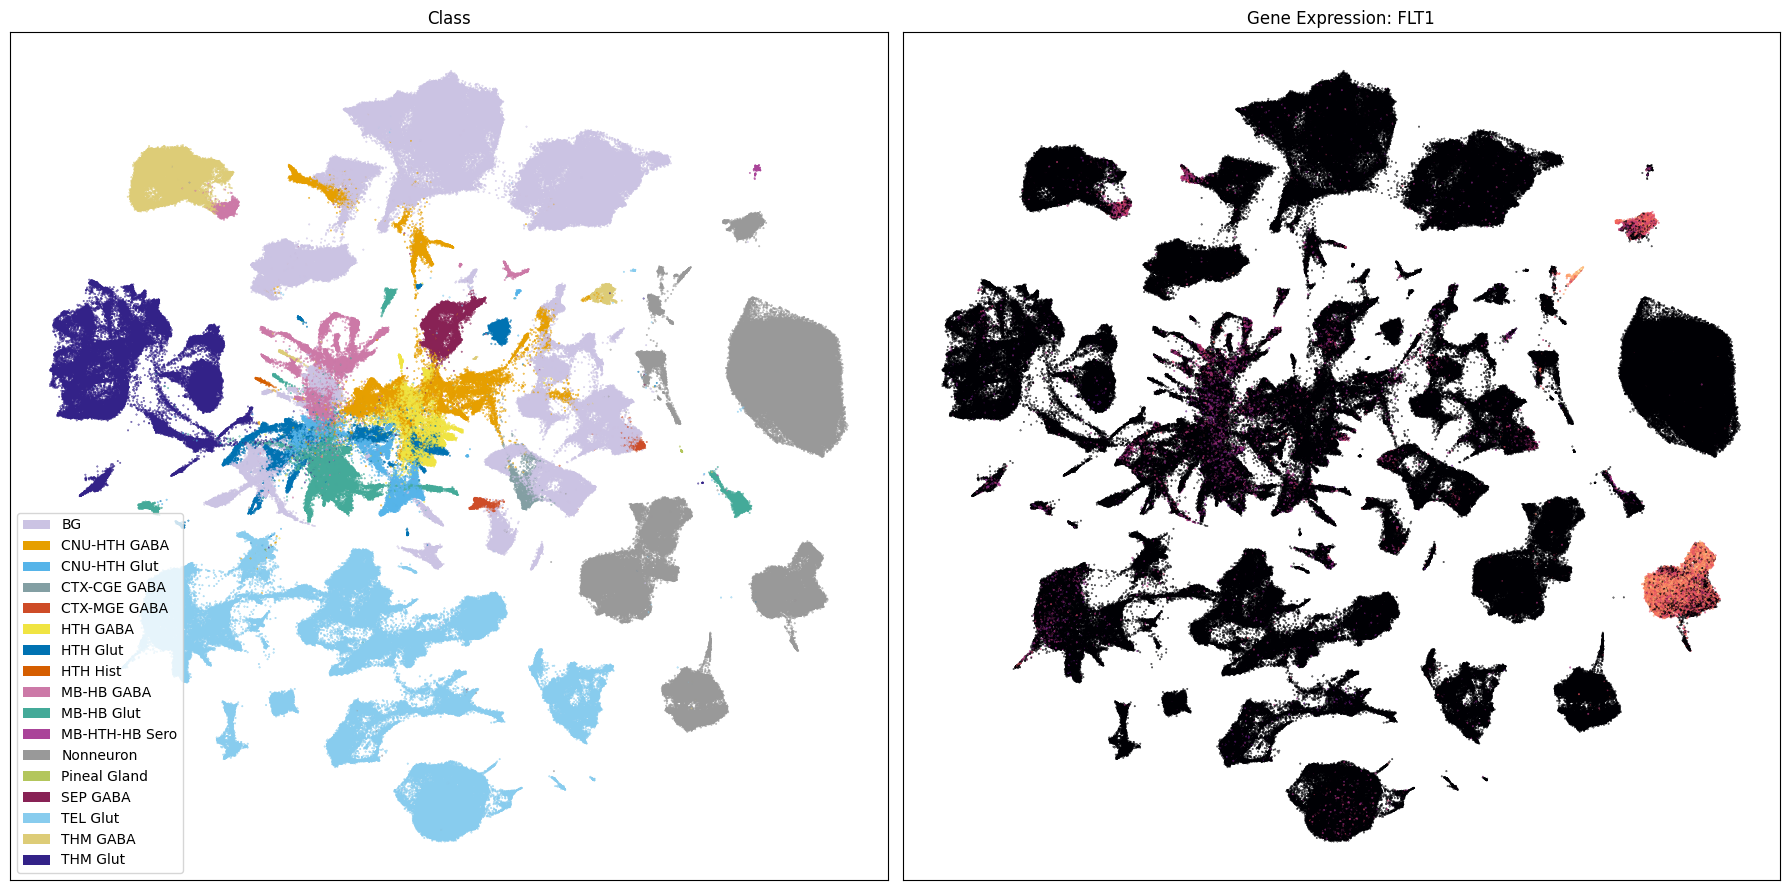

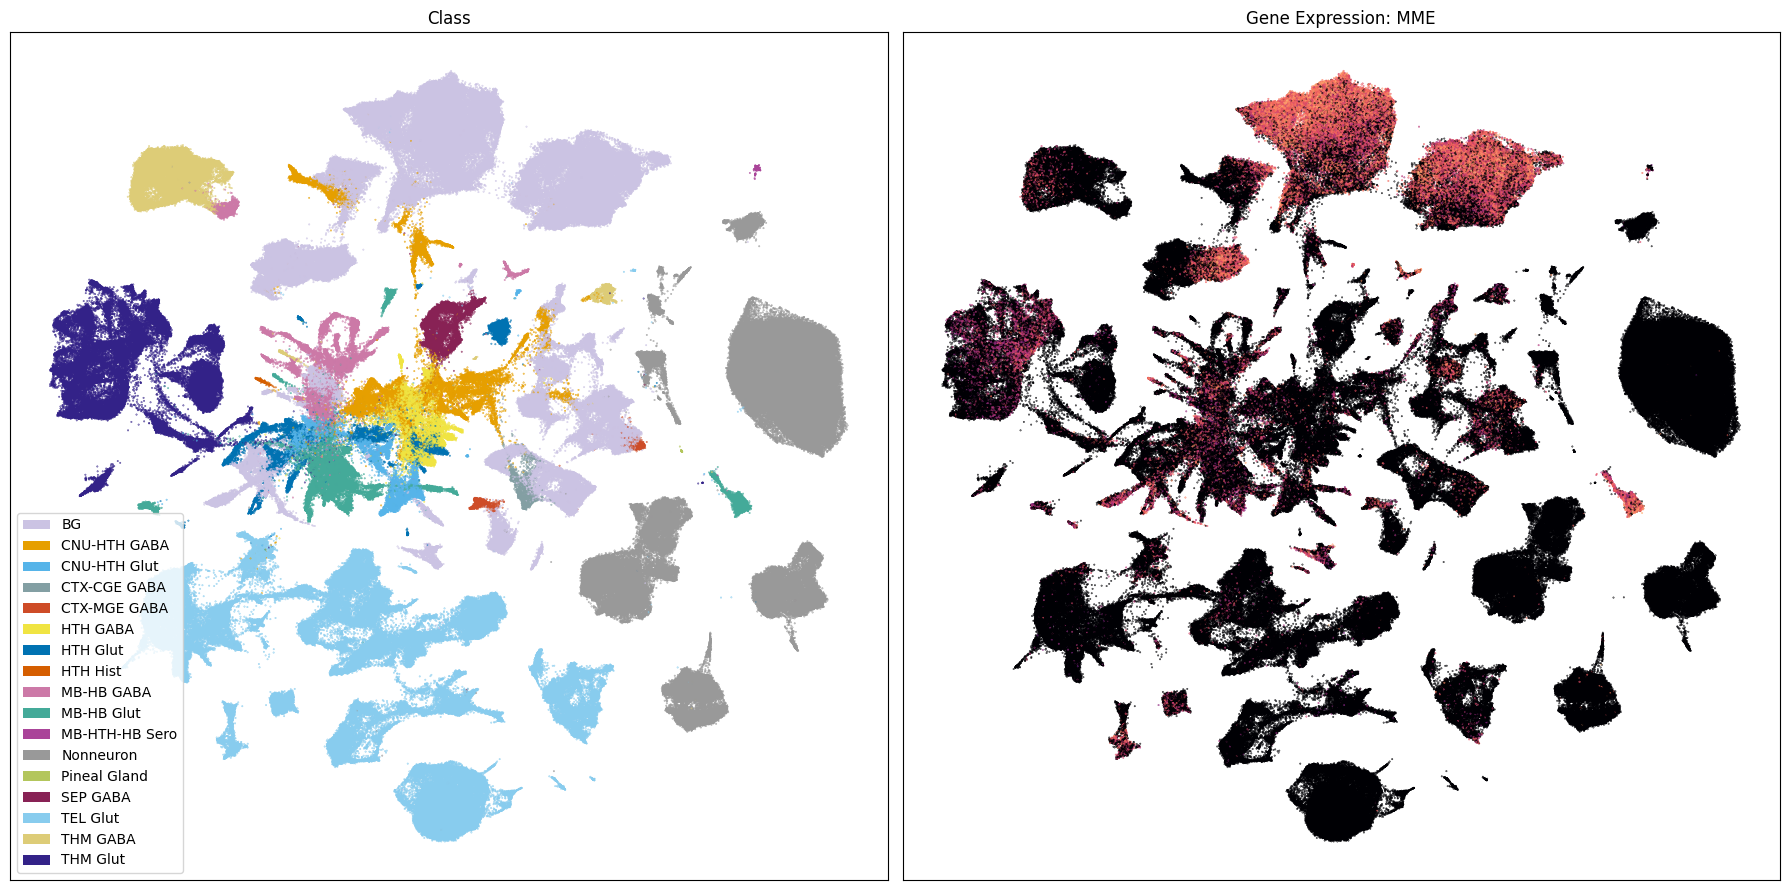

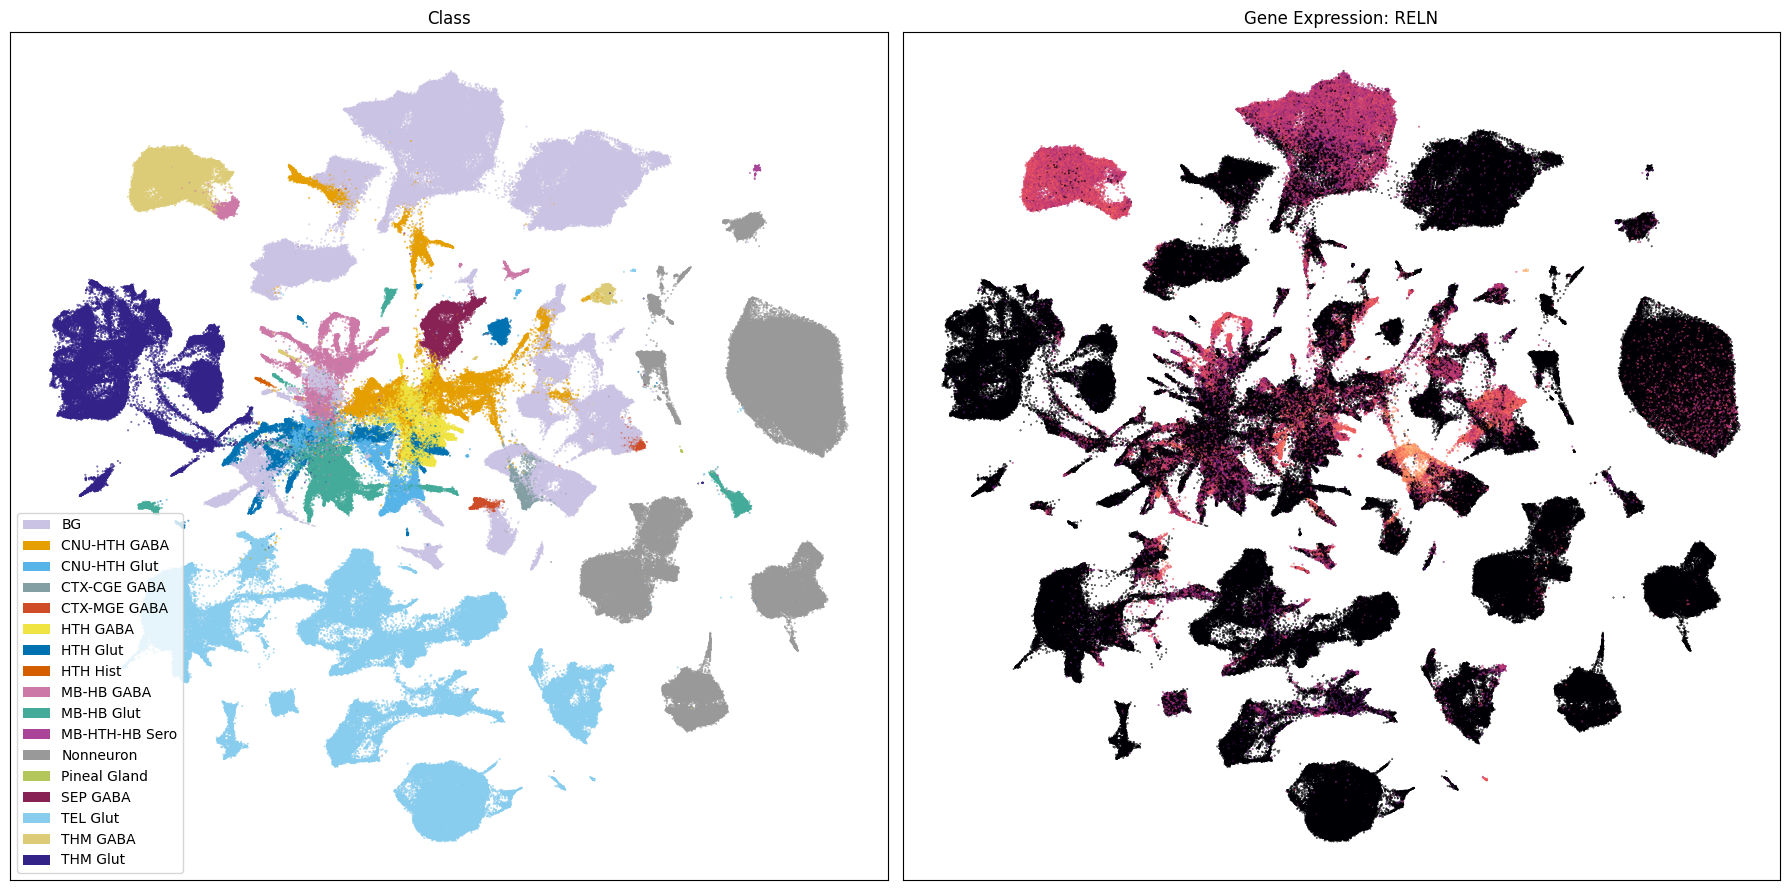

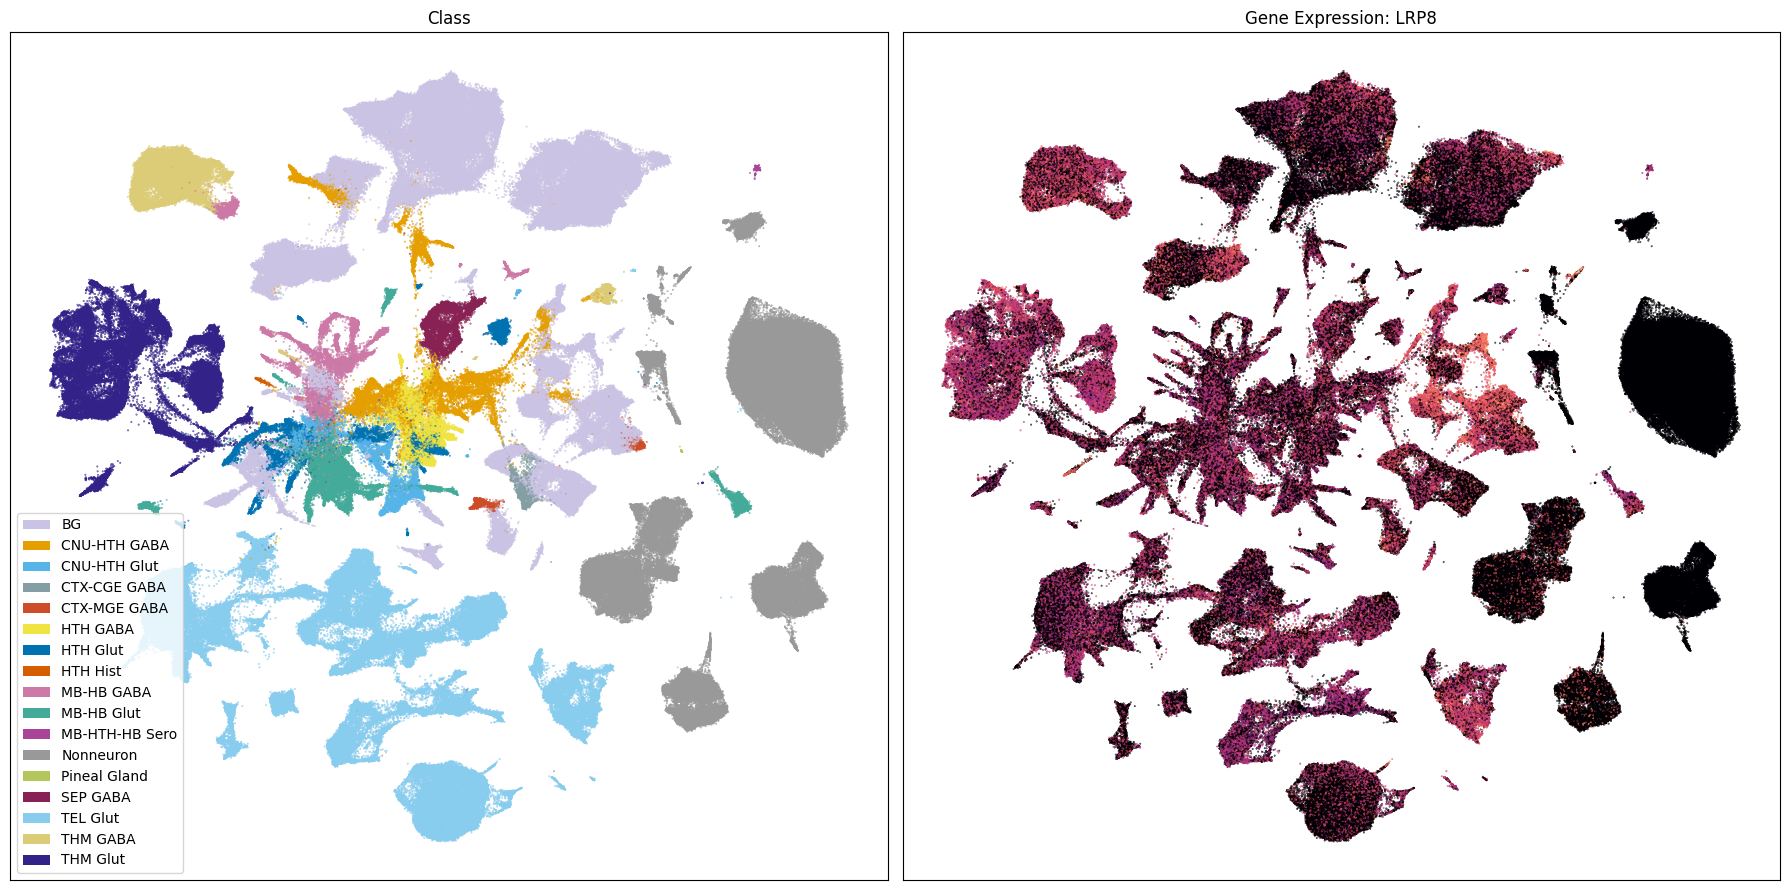

In [ ]:
term_to_plot = 'Class'

# Plot UMAPs for the first two genes in gene_names
for gene_name in gene_names:
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(18, 9)
    ax = ax.flatten()
    plot_umap(
        cell_extended['x'],
        cell_extended['y'],
        cc=cell_extended[term_to_plot + '_color'],
        labels=cell_extended[term_to_plot],
        term_orders=cell_extended[term_to_plot + '_order'],
        fig=fig,
        ax=ax[0],
    )
    ax[0].set_title(term_to_plot)
    plot_umap(
        cell_extended['x'],
        cell_extended['y'],
        val=cell_extended[gene_name],
        cmap=plt.cm.magma,
        fig=fig,
        ax=ax[1],
        colorbar=False,
    )
    ax[1].set_title(f'Gene Expression: {gene_name}')
    plt.tight_layout()
    plt.show()

Also available is the [HMBA-Subcortex taxonomy notebook](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_subcortex__clustering_analysis_and_annotation.html).